In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"C:\Project 3(Advanced Multi-Source Data Pipeline)\3.1_crypto_cleaned.csv")
df.head()

,id,symbol,name,image,current_price,market_cap,market_cap_rank,fully_diluted_valuation,total_volume,high_24h,...,ath_change_percentage,ath_date,atl,atl_change_percentage,atl_date,roi,last_updated,market_cap_category,volatility_score,supply_ratio
0,bitcoin,btc,Bitcoin,https://coin-images.coingecko.com/coins/images...,78364.000000,1.573174e+12,1.0,1.573177e+12,2.804003e+10,79625.000000,...,-37.84587,2025-10-06T10:57:42.000Z,67.810000,1.154656e+05,2013-07-05T16:00:00.000Z,Unknown,2026-09-08 09:09:20+00:00,Large,1.46872,0.999998
1,ethereum,eth,Ethereum,https://coin-images.coingecko.com/coins/images...,2476.390000,3.020876e+11,2.0,3.020876e+11,1.078214e+10,2510.030000,...,-49.93190,2025-08-24T11:21:03.000Z,0.432979,5.718430e+05,2015-10-19T16:00:00.000Z,"{'times': 41.25187165701799, 'currency': 'btc'...",2026-09-08 09:09:20+00:00,Large,0.74224,1.000000
2,tether,usdt,Tether,https://coin-images.coingecko.com/coins/images...,0.999775,1.833974e+11,3.0,1.888631e+11,5.217489e+10,0.999963,...,-24.43664,2018-07-23T16:00:00.000Z,0.572521,7.462682e+01,2015-03-01T16:00:00.000Z,Unknown,2026-09-08 09:09:20+00:00,Large,0.01227,0.971060
3,binancecoin,bnb,BNB,https://coin-images.coingecko.com/coins/images...,752.400000,1.001444e+11,4.0,1.001444e+11,1.087073e+09,760.330000,...,-45.07986,2025-10-13T00:41:24.000Z,0.039818,1.889515e+06,2017-10-18T16:00:00.000Z,Unknown,2026-09-08 09:09:20+00:00,Large,1.01562,1.000000
4,ripple,xrp,XRP,https://coin-images.coingecko.com/coins/images...,1.390000,8.716890e+10,5.0,1.389068e+11,1.895227e+09,1.410000,...,-61.88953,2025-07-17T19:40:53.000Z,0.002686,5.163287e+04,2014-05-21T16:00:00.000Z,Unknown,2026-09-08 09:09:20+00:00,Large,1.18714,0.627535


In [3]:
df.columns

Index(['id', 'symbol', 'name', 'image', 'current_price', 'market_cap',
       'market_cap_rank', 'fully_diluted_valuation', 'total_volume',
       'high_24h', 'low_24h', 'price_change_24h',
       'price_change_percentage_24h', 'market_cap_change_24h',
       'market_cap_change_percentage_24h', 'circulating_supply',
       'total_supply', 'max_supply', 'ath', 'ath_change_percentage',
       'ath_date', 'atl', 'atl_change_percentage', 'atl_date', 'roi',
       'last_updated', 'market_cap_category', 'volatility_score',
       'supply_ratio'],
      dtype='str')

# 1. Univariate Visualizations

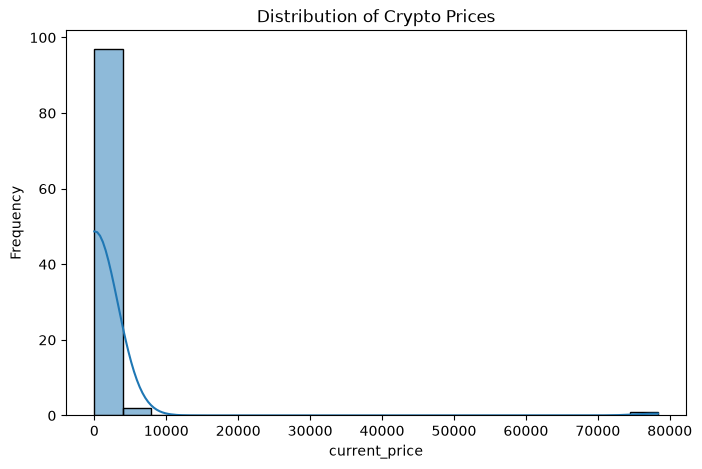

In [4]:
# Distribution of prices:

plt.figure(figsize=(8, 5))

sns.histplot(df["current_price"], kde=True)

plt.title("Distribution of Crypto Prices")
plt.xlabel("current_price")
plt.ylabel("Frequency")
plt.show()

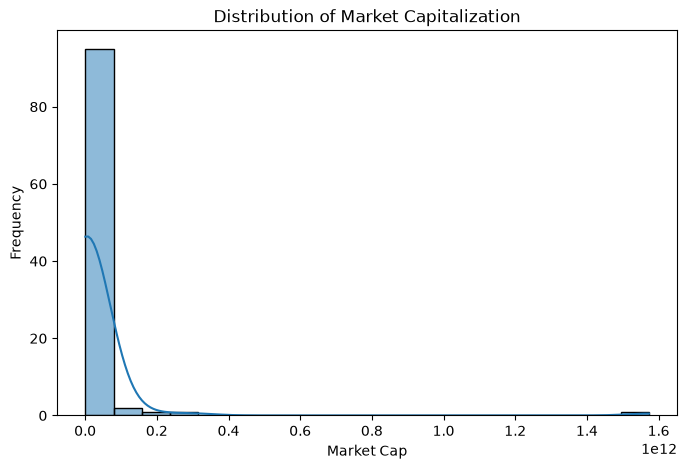

In [5]:
# Market cap distribution:

plt.figure(figsize=(8, 5))

sns.histplot(df["market_cap"], kde=True)

plt.title("Distribution of Market Capitalization")
plt.xlabel("Market Cap")
plt.ylabel("Frequency")
plt.show()

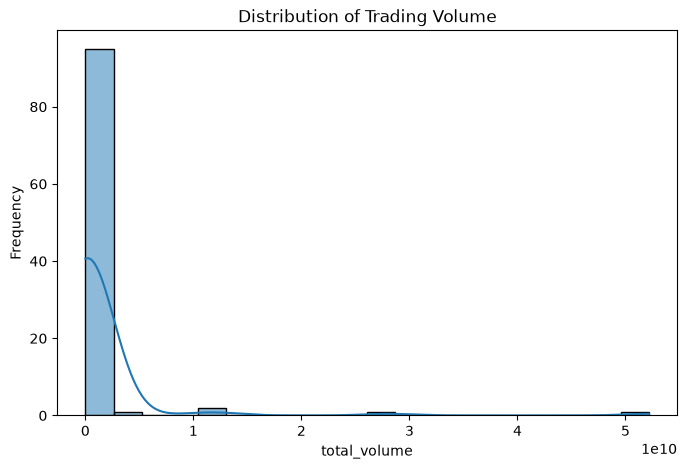

In [6]:
# Trading Volume Distribution

plt.figure(figsize=(8, 5))

sns.histplot(df["total_volume"], kde=True)

plt.title("Distribution of Trading Volume")
plt.xlabel("total_volume")
plt.ylabel("Frequency")
plt.show()

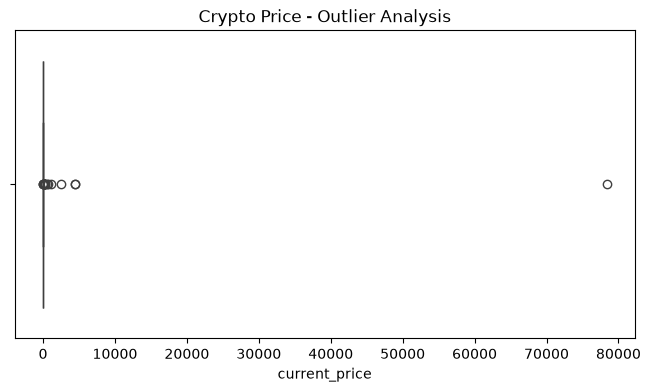

In [7]:
# Box Plot — Price
plt.figure(figsize=(8, 4))

sns.boxplot(x=df["current_price"])

plt.title("Crypto Price - Outlier Analysis")
plt.xlabel("current_price")
plt.show()

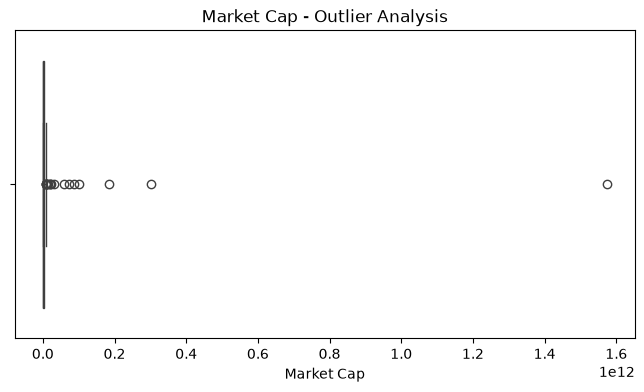

In [8]:
# Box Plot — Market Cap
plt.figure(figsize=(8, 4))

sns.boxplot(x=df["market_cap"])

plt.title("Market Cap - Outlier Analysis")
plt.xlabel("Market Cap")
plt.show()

# 2. Bivariate Visualizations

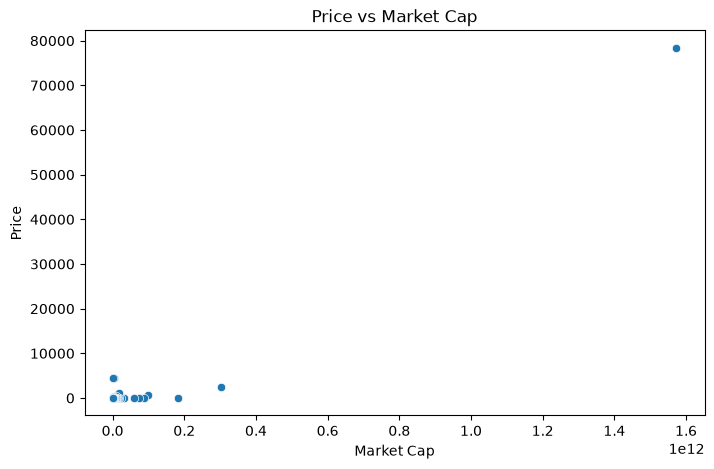

In [9]:
# current_Price vs Market Cap:

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="market_cap",
    y="current_price"
)

plt.title("Price vs Market Cap")
plt.xlabel("Market Cap")
plt.ylabel("Price")
plt.show()

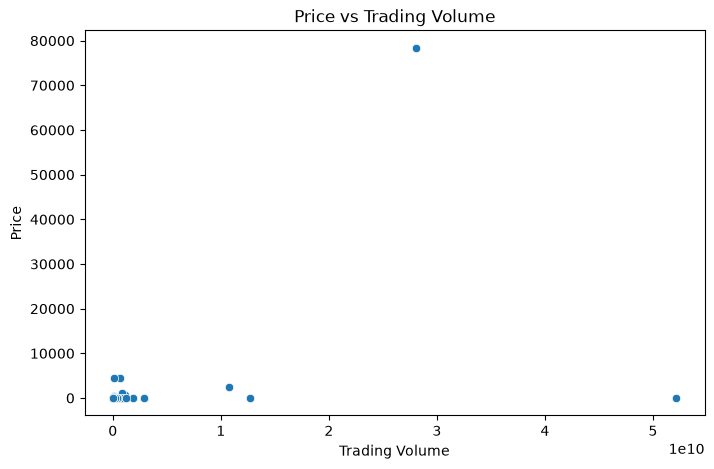

In [10]:
# current_Price vs Volume:

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="total_volume",
    y="current_price"
)

plt.title("Price vs Trading Volume")
plt.xlabel("Trading Volume")
plt.ylabel("Price")
plt.show()

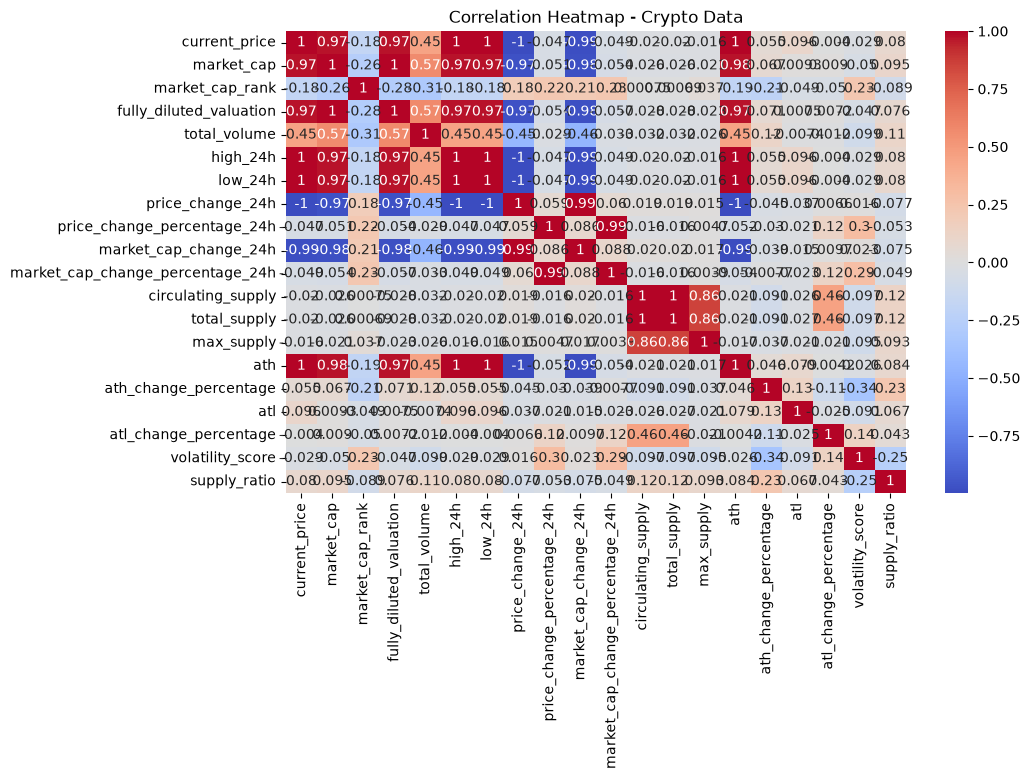

In [11]:
# Correlation Heatmap:

plt.figure(figsize=(10, 6))

corr = df.select_dtypes(include="number").corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap - Crypto Data")
plt.show()

# 3. Multivariate Visualization

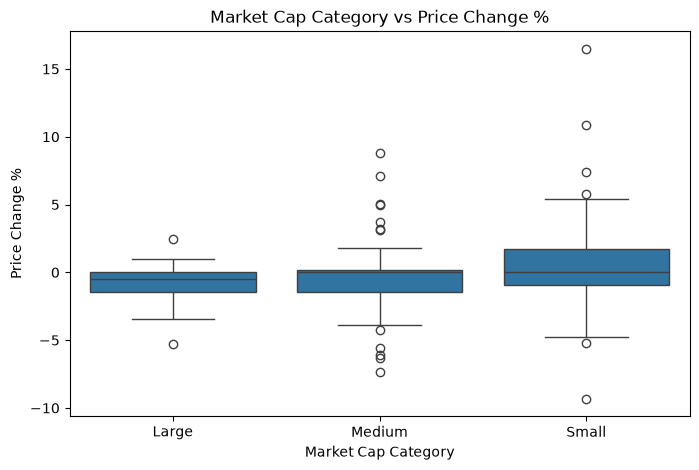

In [12]:
# Market Cap Category vs Price Change %
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="market_cap_category",
    y="price_change_percentage_24h"
)

plt.title("Market Cap Category vs Price Change %")
plt.xlabel("Market Cap Category")
plt.ylabel("Price Change %")
plt.show()

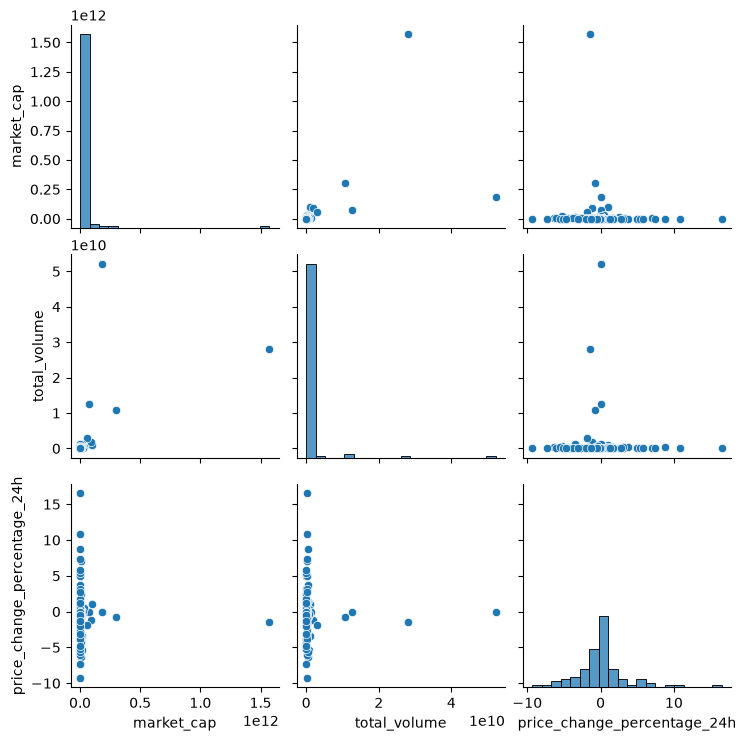

In [13]:
# pair plot
sns.pairplot(
    df[["market_cap", "total_volume", "price_change_percentage_24h"]]
)

plt.show()

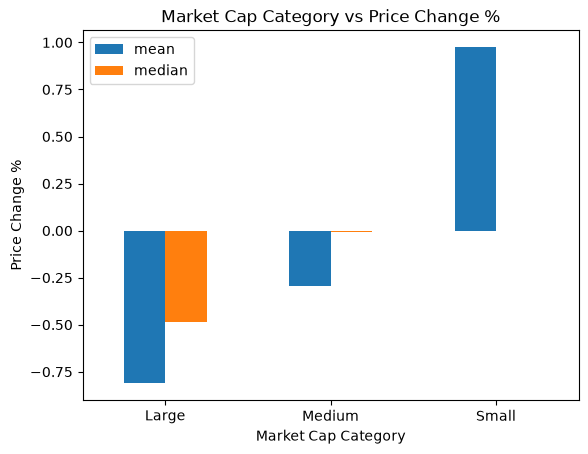

In [14]:
# Grouped Aggregations

df.groupby("market_cap_category")["price_change_percentage_24h"].agg(
    ["mean", "median"]
).plot(kind="bar")

plt.title("Market Cap Category vs Price Change %")
plt.xlabel("Market Cap Category")
plt.ylabel("Price Change %")
plt.xticks(rotation=0)
plt.show()


# 4. Advanced EDA

In [15]:
# Outlier Analysis and Impact

Q1 = df["market_cap"].quantile(0.25)
Q3 = df["market_cap"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df["market_cap"] < lower) | (df["market_cap"] > upper)]

print("Number of outliers:", len(outliers))

Number of outliers: 17


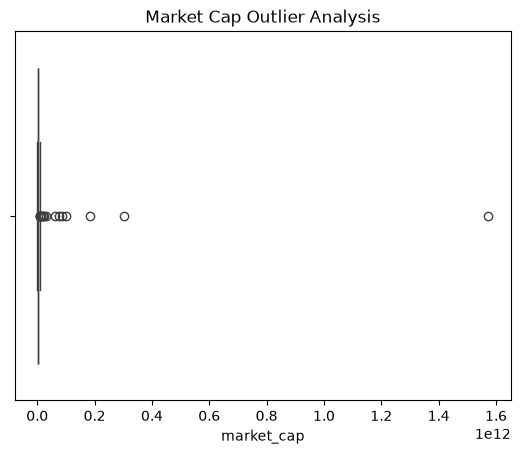

In [16]:
sns.boxplot(x=df["market_cap"])
plt.title("Market Cap Outlier Analysis")
plt.show()

In [17]:
df.columns

Index(['id', 'symbol', 'name', 'image', 'current_price', 'market_cap',
       'market_cap_rank', 'fully_diluted_valuation', 'total_volume',
       'high_24h', 'low_24h', 'price_change_24h',
       'price_change_percentage_24h', 'market_cap_change_24h',
       'market_cap_change_percentage_24h', 'circulating_supply',
       'total_supply', 'max_supply', 'ath', 'ath_change_percentage',
       'ath_date', 'atl', 'atl_change_percentage', 'atl_date', 'roi',
       'last_updated', 'market_cap_category', 'volatility_score',
       'supply_ratio'],
      dtype='str')

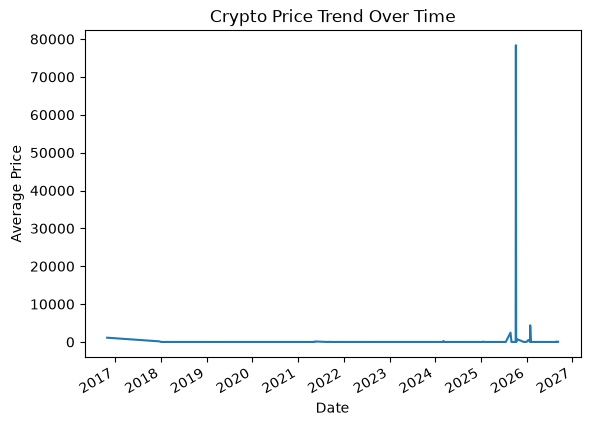

In [18]:
df["ath_date"] = pd.to_datetime(df["ath_date"])

df.groupby("ath_date")["current_price"].mean().plot()

plt.title("Crypto Price Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Average Price")
plt.show()

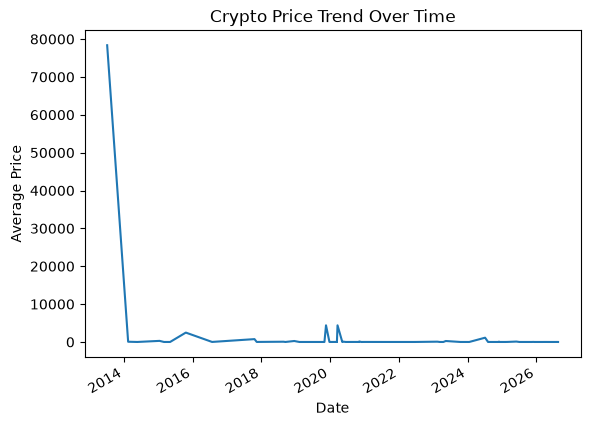

In [19]:
df["atl_date"] = pd.to_datetime(df["atl_date"])

df.groupby("atl_date")["current_price"].mean().plot()

plt.title("Crypto Price Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Average Price")
plt.show()

# 5. Insights Generation

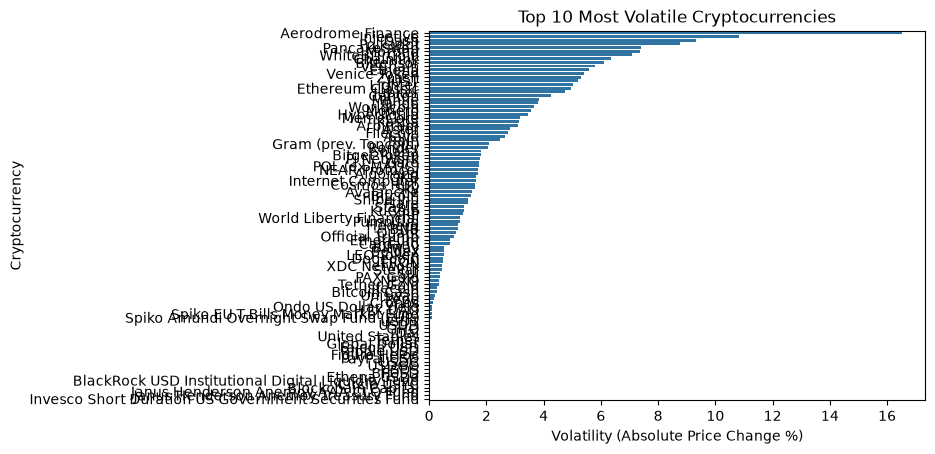

In [20]:
# Top 10 Most Volatile Cryptocurrencies

df["Volatility"] = df["price_change_percentage_24h"].abs()

high_volatility = df.sort_values(
    "Volatility", ascending=False
)[["name", "price_change_percentage_24h", "Volatility"]]


sns.barplot(
    x="Volatility",
    y="name",
    data=high_volatility
)

plt.title("Top 10 Most Volatile Cryptocurrencies")
plt.xlabel("Volatility (Absolute Price Change %)")
plt.ylabel("Cryptocurrency")
plt.show()

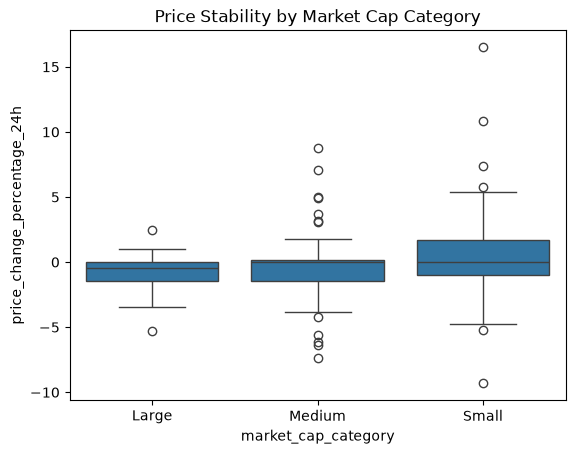

In [21]:
# Price Stability by Market Cap Category

sns.boxplot(
    x="market_cap_category",
    y="price_change_percentage_24h",
    data=df
)

plt.title("Price Stability by Market Cap Category")
plt.show()

In [22]:
df.to_csv("Visualized_Crypto_data.csv", index = False)